
# 04 — Partial และ Cumulative Beam Blockage ด้วย wradlib
## จาก Terrain–Beam Geometry สู่ PBB และ CBB

**Google Colab teaching notebook | Geography · Geoinformatics · Environmental Science · Radar Meteorology**

Notebook นี้ต่อจาก

- **00 — Setup and Download SRTM DEM**
- **01 — SRTM DEM Preprocessing for Radar–Terrain Analysis**
- **02 — Radar Beam Geometry for Terrain Analysis**
- **03 — Terrain Sampling and Terrain–Beam Profiles**

ใน Notebook 03 เราเห็นว่า terrain สามารถอยู่ต่ำกว่า beam centre แต่ยังทะลุเข้าไปในส่วนล่างของ beam envelope ได้

Notebook 04 จะตอบคำถามต่อว่า

> **หน้าตัดของลำบีมถูกภูมิประเทศบดบังเป็นสัดส่วนเท่าใด และการบดบังนั้นสะสมไปตามแนวลำบีมอย่างไร?**

เราจะคำนวณ

$$
PBB = \mathrm{Partial\ Beam\ Blockage}
$$

และ

$$
CBB = \mathrm{Cumulative\ Beam\ Blockage}
$$

โดยใช้ `wradlib` และตรวจสอบผลเชิงคณิตศาสตร์อีกชั้นหนึ่ง เพื่อให้นิสิตเข้าใจทั้ง **สมการ** และ **library implementation**

ในบทนี้ใช้ **CAND_A ที่ elevation 0.5°** เป็นกรณีศึกษาเพียงหนึ่ง scenario ก่อน เพื่อเน้นกลไก ไม่ให้การเปรียบเทียบหลายสถานีกลบความเข้าใจพื้นฐาน



### รูปแบบสมการสำหรับ Google Colab

Notebook นี้ใช้

- `$ ... $` สำหรับสมการในบรรทัด
- `$$ ... $$` สำหรับสมการแยกบรรทัด

เพื่อให้ MathJax แสดงผลได้ถูกต้องใน Google Colab



## 1. คำถามนำของบทเรียน

1. ถ้า terrain อยู่ต่ำกว่า lower beam edge ควรได้ PBB เท่าใด?
2. ถ้า terrain ผ่าน beam centre ควรได้ PBB ประมาณเท่าใด?
3. ถ้า terrain สูงกว่า upper beam edge ควรได้ PBB เท่าใด?
4. เหตุใด PBB สามารถลดลงตาม range แต่ CBB ไม่ควรลดลง?
5. ทำไม CBB ที่ gate ด้านหลัง ridge จึงยังสูง แม้ terrain ณ gate นั้นต่ำลงแล้ว?
6. ค่า CBB = 0.5 มีความหมายเชิงกายภาพอย่างไร?
7. เหตุใด terrain height, beam height และ beam radius ต้องอยู่ในหน่วยเดียวกัน?
8. การใช้ standard $k=4/3$ มีข้อจำกัดอย่างไรในสภาวะ anomalous propagation?



## 2. Learning Outcomes

เมื่อจบ Notebook นี้ นิสิตควรสามารถ

- อธิบายความหมายทางเรขาคณิตของ PBB
- เขียนความสัมพันธ์ของ terrain height, beam-centre height และ beam radius
- คำนวณ PBB ด้วย `wradlib.qual.beam_block_frac`
- ตรวจสมการ PBB ด้วย circle-segment formulation
- อธิบายความแตกต่างระหว่าง PBB และ CBB
- คำนวณ CBB ด้วย `wradlib.qual.cum_beam_block_frac`
- ตรวจว่า CBB ไม่ลดลงตาม range
- สร้าง PBB/CBB map บนระบบพิกัด UTM
- อ่าน PBB/CBB ตาม selected azimuths
- คำนวณระยะแรกที่ CBB ถึง 10% และ 50%
- แยก physical interpretation ออกจากเกณฑ์ classification ที่ผู้วิเคราะห์กำหนด
- จัดเก็บ arrays, tables และ metadata สำหรับ workflow ที่ reproducible



# Part A — หลักการของ Partial Beam Blockage

## 3. Beam Cross Section

เพื่อคำนวณ PBB เราประมาณหน้าตัดลำบีมที่ระยะหนึ่งเป็นวงกลมรัศมี

$$
a
$$

โดย $a$ คือ **half-power beam radius**

สำหรับ beamwidth $\beta$

$$
a(r)
\approx
r\tan\left(\frac{\beta}{2}\right)
$$

ใน `wradlib` ใช้ `half_power_radius()` เพื่อคำนวณปริมาณนี้ตาม range



## 4. ตำแหน่ง Terrain เมื่อเทียบกับ Beam Centre

ให้

$$
H_t
=
\mathrm{terrain\ height}
$$

$$
H_b
=
\mathrm{beam\ centre\ height}
$$

แล้วกำหนด

$$
y
=
H_t-H_b
$$

ความหมายคือ

- $y<0$ : terrain ต่ำกว่า beam centre
- $y=0$ : terrain ผ่าน beam centre
- $y>0$ : terrain สูงกว่า beam centre

เมื่อ normalize ด้วย beam radius

$$
q
=
\frac{y}{a}
$$

เราจะได้สามกรณีหลัก:

$$
q\le-1
\Rightarrow
PBB=0
$$

$$
-1<q<1
$$

คือ terrain ตัดผ่านหน้าตัด beam บางส่วน

$$
q\ge1
\Rightarrow
PBB=1
$$



## 5. Circle-Segment Formulation ของ PBB

สำหรับกรณี partial interception

$$
-1<q<1
$$

สัดส่วนพื้นที่หน้าตัดลำบีมที่ถูกบังสามารถเขียนในรูป normalized ได้เป็น

$$
PBB
=
\frac{
q\sqrt{1-q^2}
+
\sin^{-1}(q)
+
\frac{\pi}{2}
}{
\pi
}
$$

โดย

$$
q=\frac{H_t-H_b}{a}
$$

เมื่อ terrain ผ่าน beam centre

$$
q=0
$$

จึงได้

$$
PBB=\frac{1}{2}
$$

หรือ 50%

สมการ simplified beam-interception นี้เป็นแนวคิดที่ `wradlib.qual.beam_block_frac()` ใช้ และอ้างอิงวิธีของ Bech et al. (2003)



## 6. PBB ไม่ใช่ CBB

สมมติ ray หนึ่งมี PBB ตาม range เป็น

$$
0.00,\ 0.10,\ 0.45,\ 0.20,\ 0.05
$$

ถ้าดูเฉพาะ local PBB อาจเหมือนว่า beam กลับมาเกือบ clear หลังผ่าน ridge

แต่ส่วนของ beam ที่ถูก terrain บังด้านหน้าไม่สามารถกลับคืนมาที่ gate ด้านหลังได้

จึงต้องพิจารณา cumulative blockage

$$
CBB_i
=
\max
\left(
PBB_1,PBB_2,\dots,PBB_i
\right)
$$

ตัวอย่างจึงได้

$$
0.00,\ 0.10,\ 0.45,\ 0.45,\ 0.45
$$

ดังนั้น CBB ต้อง **ไม่ลดลงตาม range** ภายใน ray เดียวกัน



## 7. เกณฑ์ที่ใช้ในแบบเรียน

เพื่อช่วยการสรุปผล เราจะใช้เกณฑ์เชิงวิเคราะห์

$$
CBB<0.10
$$

เป็น **Clear / weakly affected**

$$
0.10\le CBB<0.50
$$

เป็น **Partial blockage**

และ

$$
CBB\ge0.50
$$

เป็น **Severe blockage**

> เกณฑ์ 0.10 และ 0.50 เป็น analysis thresholds สำหรับการเรียนและการเปรียบเทียบภายในโครงการ ไม่ใช่กฎทางฟิสิกส์สากลสำหรับทุก radar network



## 8. ข้อจำกัดทางฟิสิกส์

PBB/CBB ในบทนี้ขึ้นกับ assumptions สำคัญ ได้แก่

- DEM representation
- antenna altitude
- nominal beamwidth
- elevation angle
- effective Earth radius
- standard refraction assumption
- simplified interception geometry

ดังนั้นในสภาวะ superrefraction หรือ anomalous propagation เส้นทางลำบีมจริงอาจต่างจาก standard $k=4/3$ model


In [1]:

# ============================================================
# STEP 1 — Install packages required by this notebook
# ============================================================

import sys
import subprocess
import importlib.util

required_packages = {
    "wradlib": "wradlib==2.9.5",
    "rasterio": "rasterio",
    "pyproj": "pyproj",
}

to_install = []

for module_name, pip_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        to_install.append(pip_name)

if to_install:
    print("Installing:", to_install)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q"]
        + to_install
    )
else:
    print("Required packages are already available.")

print("✓ Package check complete")


Installing: ['wradlib==2.9.5']
✓ Package check complete


In [2]:

# ============================================================
# STEP 2 — Imports and software environment
# ============================================================

from pathlib import Path
import json
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe

import rasterio
from rasterio.transform import rowcol
from matplotlib.patches import Circle
from matplotlib.colors import LightSource

from pyproj import CRS

import wradlib as wrl

print("Software environment")
print("--------------------")
print("Python      :", platform.python_version())
print("wradlib     :", wrl.__version__)
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("Matplotlib  :", mpl.__version__)
print("Rasterio    :", rasterio.__version__)

if wrl.__version__ != "2.9.5":
    print(
        "\n⚠ This teaching notebook was developed against "
        "wradlib 2.9.5. Review API compatibility if using "
        f"version {wrl.__version__}."
    )


Software environment
--------------------
Python      : 3.13.15
wradlib     : 2.9.5
NumPy       : 2.1.3
Pandas      : 2.2.3
Matplotlib  : 3.10.0
Rasterio    : 1.5.1


In [3]:

# ============================================================
# STEP 3 — Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [4]:

# ============================================================
# STEP 4 — Course paths and visual standards
# ============================================================

COURSE_ROOT = Path(
    "/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage"
)

PROCESSED_DEM_DIR = COURSE_ROOT / "01_processed_data" / "dem"
METADATA_DIR = COURSE_ROOT / "02_metadata"
RESULTS_DIR = COURSE_ROOT / "03_results"
FIGURES_DIR = COURSE_ROOT / "04_figures"
TABLES_DIR = COURSE_ROOT / "05_tables"

for p in [
    METADATA_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

DEM_PATH = (
    PROCESSED_DEM_DIR /
    "Nan_Radar_SRTM_DEM_1km_UTM47N_MAX.tif"
)

SITE_CSV = (
    METADATA_DIR /
    "01_site_elevation_native_vs_1km_MAX.csv"
)

GEOMETRY_JSON = (
    METADATA_DIR /
    "02_radar_beam_geometry_parameters.json"
)

TERRAIN_PROFILE_METADATA = (
    METADATA_DIR /
    "03_CAND_A_Terrain_Beam_Profile_Metadata.json"
)

TERRAIN_POLAR_NPZ = (
    RESULTS_DIR /
    "03_CAND_A_TerrainPolar_0p5deg_360x480.npz"
)

DEM_CMAP = "terrain"

BLOCKAGE_CMAP = "PuRd"
BLOCKAGE_VMIN = 0.0
BLOCKAGE_VMAX = 1.0

CURRENT_MARKER = "*"
CURRENT_FACE = "darkorange"
CURRENT_EDGE = "black"

CANDIDATE_MARKER = "^"
CANDIDATE_FACE = "white"
CANDIDATE_EDGE = "black"

PBB_LINE_COLOR = mpl.colormaps[BLOCKAGE_CMAP](0.60)
CBB_LINE_COLOR = mpl.colormaps[BLOCKAGE_CMAP](0.92)
TERRAIN_PROFILE_COLOR = mpl.colormaps[DEM_CMAP](0.48)

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

print("DEM                :", DEM_PATH)
print("Terrain polar grid :", TERRAIN_POLAR_NPZ)


DEM                : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/01_processed_data/dem/Nan_Radar_SRTM_DEM_1km_UTM47N_MAX.tif
Terrain polar grid : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/03_results/03_CAND_A_TerrainPolar_0p5deg_360x480.npz



# Part B — เชื่อมผลจาก Notebook 01–03

## 9. Dependency Check

Notebook 04 ใช้

- DEM 1 km จาก Notebook 01
- site metadata จาก Notebook 01
- radar geometry parameters จาก Notebook 02
- terrain polar product จาก Notebook 03

PBB/CBB จะคำนวณจาก **wradlib geometry** โดยตรง แล้ว sample DEM ใหม่บนพิกัดนั้น

terrain polar product จาก Notebook 03 จะใช้เป็น independent cross-check


In [5]:

# ============================================================
# STEP 5 — Dependency check and load previous outputs
# ============================================================

dependency_checks = {
    "1-km UTM DEM": DEM_PATH.exists(),
    "Radar-site metadata": SITE_CSV.exists(),
    "Beam-geometry metadata": GEOMETRY_JSON.exists(),
    "Notebook 03 metadata": TERRAIN_PROFILE_METADATA.exists(),
    "Notebook 03 terrain polar NPZ": TERRAIN_POLAR_NPZ.exists(),
}

for label, ok in dependency_checks.items():
    print(("✓" if ok else "✗"), label)

if not all(dependency_checks.values()):
    raise RuntimeError(
        "Required outputs from Notebook 01–03 are incomplete."
    )

sites = pd.read_csv(SITE_CSV)

with open(
    GEOMETRY_JSON,
    "r",
    encoding="utf-8",
) as f:
    geometry = json.load(f)

with open(
    TERRAIN_PROFILE_METADATA,
    "r",
    encoding="utf-8",
) as f:
    terrain_meta = json.load(f)

terrain03 = np.load(
    TERRAIN_POLAR_NPZ
)

print("\n✓ Previous outputs loaded")


✓ 1-km UTM DEM
✓ Radar-site metadata
✓ Beam-geometry metadata
✓ Notebook 03 metadata
✓ Notebook 03 terrain polar NPZ

✓ Previous outputs loaded



## 10. Configuration ของกรณีศึกษา

ใช้

$$
\mathrm{Site}=\mathrm{CAND\_A}
$$

$$
\theta=0.5^\circ
$$

$$
\beta=1.0^\circ
$$

$$
k=\frac{4}{3}
$$

จำนวน rays และ gates คือ

$$
360\times480
$$

โดย range gate centres อยู่ที่

$$
0.25,\ 0.75,\ 1.25,\dots,239.75\ \mathrm{km}
$$


In [6]:

# ============================================================
# STEP 6 — Analysis configuration
# ============================================================

FOCUS_SITE_ID = "CAND_A"
FOCUS_ELEVATION_DEG = 0.5

SELECTED_AZIMUTHS_DEG = [
    15.0,
    80.0,
    210.0,
]

CLEAR_THRESHOLD = 0.10
SEVERE_THRESHOLD = 0.50

EARTH_RADIUS_M = float(
    geometry["earth_radius_m"]
)

K_STANDARD = float(
    geometry["k_standard"]
)

NRAYS = 360

NBINS = int(
    geometry["number_of_range_bins"]
)

RANGE_RES_M = float(
    geometry["range_resolution_m"]
)

MAX_RANGE_M = float(
    geometry["maximum_nominal_range_km"]
) * 1000.0

BEAMWIDTH_DEG = float(
    geometry["beamwidth_deg"]
)

ANTENNA_AGL_M = float(
    geometry["antenna_agl_teaching_assumption_m"]
)

site_match = sites[
    sites["site_id"] == FOCUS_SITE_ID
]

if len(site_match) != 1:
    raise ValueError(
        f"Expected exactly one site named {FOCUS_SITE_ID!r}."
    )

site = site_match.iloc[0]

RADAR_LON = float(site["longitude"])
RADAR_LAT = float(site["latitude"])
RADAR_GROUND_MSL_M = float(site["native_dem_m"])

RADAR_ALTITUDE_MSL_M = (
    RADAR_GROUND_MSL_M
    + ANTENNA_AGL_M
)

RANGE_CENTERS_M = (
    np.arange(NBINS, dtype=float)
    + 0.5
) * RANGE_RES_M

AZIMUTHS_ALL_DEG = np.arange(
    NRAYS,
    dtype=float,
)

print("Focus scenario")
print("--------------")
print("Site              :", FOCUS_SITE_ID)
print("Location          :", site["site_name"])
print("Longitude         :", f"{RADAR_LON:.6f}°E")
print("Latitude          :", f"{RADAR_LAT:.6f}°N")
print("Ground elevation  :", f"{RADAR_GROUND_MSL_M:.1f} m MSL")
print("Antenna AGL       :", f"{ANTENNA_AGL_M:.1f} m")
print("Radar altitude    :", f"{RADAR_ALTITUDE_MSL_M:.1f} m MSL")
print("Elevation         :", f"{FOCUS_ELEVATION_DEG:.1f}°")
print("Beamwidth         :", f"{BEAMWIDTH_DEG:.1f}°")
print("k-factor          :", f"{K_STANDARD:.6f}")
print("Grid              :", f"{NRAYS} × {NBINS}")


Focus scenario
--------------
Site              : CAND_A
Location          : Tha Nao, Phu Phiang, Nan
Longitude         : 100.815841°E
Latitude          : 18.730690°N
Ground elevation  : 235.0 m MSL
Antenna AGL       : 30.0 m
Radar altitude    : 265.0 m MSL
Elevation         : 0.5°
Beamwidth         : 1.0°
k-factor          : 1.333333
Grid              : 360 × 480


In [7]:

# ============================================================
# STEP 7 — Load analysis DEM
# ============================================================

with rasterio.open(
    DEM_PATH
) as ds:
    dem = ds.read(
        1,
        masked=True,
    )

    dem_data = np.asarray(
        dem.filled(np.nan),
        dtype=np.float32,
    )

    dem_transform = ds.transform
    dem_crs = CRS.from_user_input(ds.crs)
    dem_bounds = ds.bounds
    dem_nodata = ds.nodata
    dem_res = ds.res

print("DEM CRS       :", dem_crs)
print("DEM resolution:", dem_res)
print("DEM shape     :", dem.shape)
print("DEM bounds    :", dem_bounds)
print(
    "Valid DEM (%) :",
    f"{100*np.isfinite(dem_data).mean():.3f}"
)


DEM CRS       : PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32647"]]
DEM resolution: (1000.0, 1000.0)
DEM shape     : (552, 529)
DEM bounds    : BoundingBox(left=440000.0, bottom=1822000.0, right=969000.0, top=2374000.0)
Valid DEM (%) : 100.000



# Part C — สร้าง Radar Geometry ด้วย wradlib

## 11. ทำไมคำนวณ Geometry ใหม่ในบทนี้?

Notebook 02–03 สร้าง geometry ด้วยสมการโดยตรงเพื่อให้เข้าใจหลักการ

Notebook 04 เปลี่ยนไปใช้ `wradlib.georef.polar.spherical_to_proj()` ซึ่งคำนวณตำแหน่ง radar gates ใน CRS ของ DEM

นี่เป็นจุดเปลี่ยนจาก

$$
\mathrm{Teaching\ equation}
$$

ไปสู่

$$
\mathrm{Research\ workflow}
$$

แต่เรายังตรวจผลกับ Notebook 03 ไม่ใช้ library แบบ blind trust


In [8]:

# ============================================================
# STEP 8 — Build wradlib polar geometry
# ============================================================

az2d = np.repeat(
    AZIMUTHS_ALL_DEG[:, None],
    NBINS,
    axis=1,
)

range2d = np.repeat(
    RANGE_CENTERS_M[None, :],
    NRAYS,
    axis=0,
)

el2d = np.full(
    (NRAYS, NBINS),
    FOCUS_ELEVATION_DEG,
    dtype=float,
)

sitecoords = (
    RADAR_LON,
    RADAR_LAT,
    RADAR_ALTITUDE_MSL_M,
)

coords = wrl.georef.polar.spherical_to_proj(
    range2d,
    az2d,
    el2d,
    sitecoords,
    crs=dem_crs,
    ke=K_STANDARD,
)

coords = np.asarray(
    coords,
    dtype=np.float64,
)

gate_x_m = coords[..., 0].astype(np.float32)
gate_y_m = coords[..., 1].astype(np.float32)
beam_center_msl_m = coords[..., 2].astype(np.float32)

beam_radius_m = np.asarray(
    wrl.util.half_power_radius(
        RANGE_CENTERS_M,
        BEAMWIDTH_DEG,
    ),
    dtype=np.float32,
)

beam_radius_2d = np.broadcast_to(
    beam_radius_m[None, :],
    (NRAYS, NBINS),
)

print("wradlib geometry")
print("----------------")
print("Coordinates shape :", coords.shape)
print("Beam height shape :", beam_center_msl_m.shape)
print("Beam radius shape :", beam_radius_m.shape)
print(
    "Beam radius at final gate:",
    f"{beam_radius_m[-1]:.1f} m"
)


wradlib geometry
----------------
Coordinates shape : (360, 480, 3)
Beam height shape : (360, 480)
Beam radius shape : (480,)
Beam radius at final gate: 2092.2 m



## 12. ตรวจความสอดคล้องกับ Notebook 03

เราจะเปรียบเทียบ terrain ที่ sample จาก wradlib gate coordinates กับ terrain polar grid จาก Notebook 03

ความแตกต่างเล็กน้อยอาจเกิดจากรายละเอียดของ geometry implementation และการ map coordinate ลง raster cell

จุดประสงค์คือ diagnostic comparison ไม่ใช่บังคับให้ arrays เหมือนกันทุก cell แบบ exact


In [9]:

# ============================================================
# STEP 9 — Sample DEM at wradlib gate coordinates
# ============================================================

flat_x = gate_x_m.ravel()
flat_y = gate_y_m.ravel()

rows, cols = rowcol(
    dem_transform,
    flat_x,
    flat_y,
)

rows = np.asarray(rows, dtype=int)
cols = np.asarray(cols, dtype=int)

inside = (
    (rows >= 0)
    & (rows < dem_data.shape[0])
    & (cols >= 0)
    & (cols < dem_data.shape[1])
)

terrain_flat = np.full(
    flat_x.shape,
    np.nan,
    dtype=np.float32,
)

terrain_flat[inside] = dem_data[
    rows[inside],
    cols[inside],
]

terrain_msl_m = terrain_flat.reshape(
    NRAYS,
    NBINS,
)

missing_mask = ~np.isfinite(
    terrain_msl_m
)

missing_pct = (
    100.0
    * missing_mask.mean()
)

print(
    "Missing terrain:",
    f"{missing_pct:.3f}%"
)

if missing_pct > 1.0:
    raise RuntimeError(
        "More than 1% of the wradlib polar grid lacks DEM data."
    )

terrain03_arr = np.asarray(
    terrain03["terrain_msl_m"],
    dtype=np.float32,
)

if terrain03_arr.shape != terrain_msl_m.shape:
    raise ValueError(
        "Notebook 03 terrain grid has an unexpected shape."
    )

both_valid = (
    np.isfinite(terrain03_arr)
    & np.isfinite(terrain_msl_m)
)

terrain_difference = (
    terrain_msl_m
    - terrain03_arr
)

if both_valid.any():
    terrain_match_pct = (
        100.0
        * np.isclose(
            terrain_msl_m[both_valid],
            terrain03_arr[both_valid],
            atol=0.01,
        ).mean()
    )

    terrain_mae_m = float(
        np.mean(
            np.abs(
                terrain_difference[both_valid]
            )
        )
    )
else:
    terrain_match_pct = np.nan
    terrain_mae_m = np.nan

print(
    "Near-exact terrain-cell agreement with Notebook 03:",
    f"{terrain_match_pct:.2f}%"
)
print(
    "Mean absolute terrain difference:",
    f"{terrain_mae_m:.2f} m"
)


Missing terrain: 0.000%
Near-exact terrain-cell agreement with Notebook 03: 21.38%
Mean absolute terrain difference: 70.05 m


In [10]:

# ============================================================
# STEP 10 — Beam lower/upper half-power edges
# ============================================================

beam_lower_msl_m = (
    beam_center_msl_m
    - beam_radius_2d
)

beam_upper_msl_m = (
    beam_center_msl_m
    + beam_radius_2d
)

print("At the final range gate:")
print(
    "Beam centre:",
    f"{beam_center_msl_m[0, -1]:.1f} m MSL"
)
print(
    "Beam radius:",
    f"{beam_radius_2d[0, -1]:.1f} m"
)
print(
    "Lower edge :",
    f"{beam_lower_msl_m[0, -1]:.1f} m MSL"
)
print(
    "Upper edge :",
    f"{beam_upper_msl_m[0, -1]:.1f} m MSL"
)


At the final range gate:
Beam centre: 5736.0 m MSL
Beam radius: 2092.2 m
Lower edge : 3643.8 m MSL
Upper edge : 7828.2 m MSL



# Part D — เข้าใจ PBB ก่อนเรียก Function

## 13. Figure 1 — PBB จากพื้นที่หน้าตัดของ Beam

เมื่อ terrain อยู่ต่ำกว่า lower edge:

$$
PBB=0
$$

เมื่อ terrain ผ่าน centre:

$$
PBB=0.5
$$

เมื่อ terrain สูงกว่า upper edge:

$$
PBB=1
$$

บริเวณที่ระบายด้วยโทน `PuRd` แทนส่วนของ beam cross section ที่ถูก terrain บดบัง


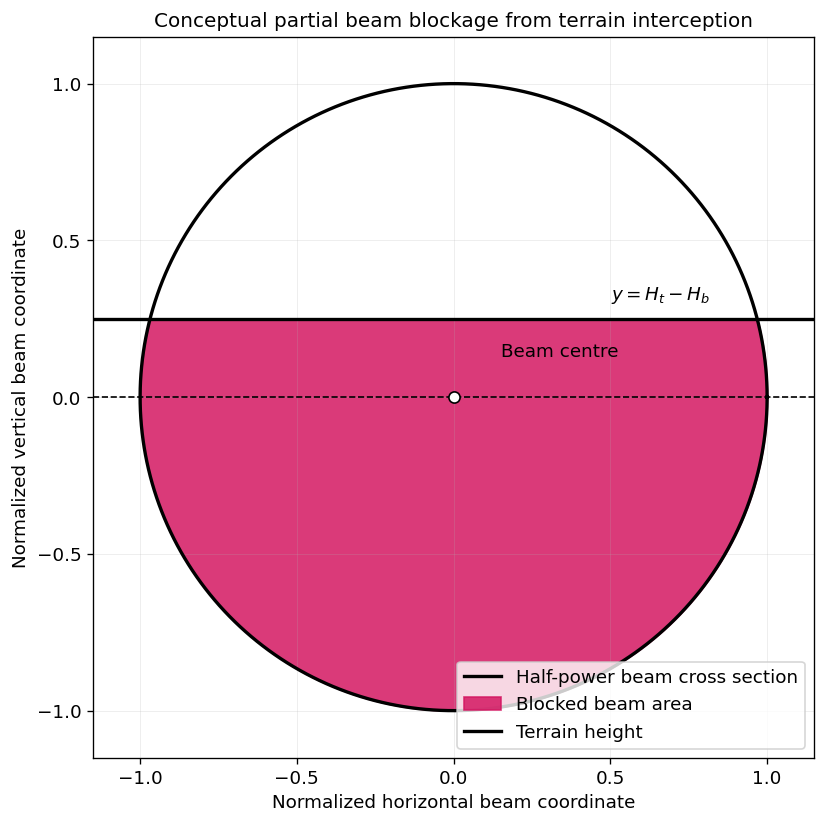

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig04_01_Conceptual_Partial_Beam_Blockage.png


In [11]:

# ============================================================
# STEP 11 — Figure 1: conceptual PBB geometry
# ============================================================

theta = np.linspace(
    0.0,
    2.0 * np.pi,
    800,
)

circle_x = np.cos(theta)
circle_y = np.sin(theta)

terrain_level = 0.25

x_fill = np.linspace(
    -1.0,
    1.0,
    1000,
)

lower_circle = -np.sqrt(
    np.maximum(
        0.0,
        1.0 - x_fill**2,
    )
)

upper_circle = np.sqrt(
    np.maximum(
        0.0,
        1.0 - x_fill**2,
    )
)

blocked_top = np.minimum(
    terrain_level,
    upper_circle,
)

mask = (
    blocked_top >= lower_circle
)

fig, ax = plt.subplots(
    figsize=(7.0, 7.0)
)

ax.plot(
    circle_x,
    circle_y,
    linewidth=2.0,
    color="black",
    label="Half-power beam cross section",
)

ax.fill_between(
    x_fill[mask],
    lower_circle[mask],
    blocked_top[mask],
    color=mpl.colormaps[BLOCKAGE_CMAP](0.72),
    alpha=0.85,
    label="Blocked beam area",
)

ax.axhline(
    0.0,
    linewidth=1.0,
    linestyle="--",
    color="black",
)

ax.axhline(
    terrain_level,
    linewidth=2.0,
    color="black",
    label="Terrain height",
)

ax.scatter(
    [0.0],
    [0.0],
    s=45,
    facecolor="white",
    edgecolor="black",
    zorder=6,
)

ax.annotate(
    "Beam centre",
    xy=(0.0, 0.0),
    xytext=(0.15, 0.13),
    textcoords="data",
)

ax.text(
    0.66,
    terrain_level + 0.06,
    r"$y=H_t-H_b$",
    ha="center",
)

ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.set_xlabel(
    "Normalized horizontal beam coordinate"
)
ax.set_ylabel(
    "Normalized vertical beam coordinate"
)
ax.set_title(
    "Conceptual partial beam blockage from terrain interception"
)

ax.legend(
    loc="lower right",
)

ax.grid(
    True,
    linewidth=0.35,
    alpha=0.35,
)

fig.tight_layout()

fig1_path = (
    FIGURES_DIR /
    "Fig04_01_Conceptual_Partial_Beam_Blockage.png"
)

fig.savefig(
    fig1_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig1_path)



## 14. คำนวณ PBB ด้วย wradlib

`wradlib.qual.beam_block_frac()` ต้องได้รับ

1. terrain height
2. beam-centre height
3. half-power beam radius

และทั้งสามปริมาณต้องอยู่ในหน่วยเดียวกัน

สำหรับ missing DEM เราใช้ค่าต่ำชั่วคราวเฉพาะตอนคำนวณ แล้ว mask ตำแหน่งนั้นกลับเป็น `NaN` หลังคำนวณ


In [12]:

# ============================================================
# STEP 12 — Calculate PBB with wradlib
# ============================================================

terrain_for_calc = (
    terrain_msl_m.copy()
)

terrain_for_calc[
    missing_mask
] = -500.0

with np.errstate(
    invalid="ignore",
    divide="ignore",
):
    pbb = wrl.qual.beam_block_frac(
        terrain_for_calc,
        beam_center_msl_m,
        beam_radius_2d,
    )

pbb = np.asarray(
    pbb,
    dtype=np.float32,
)

pbb = np.clip(
    pbb,
    0.0,
    1.0,
)

pbb[
    missing_mask
] = np.nan

print("PBB")
print("---")
print("Minimum:", f"{np.nanmin(pbb):.4f}")
print("Maximum:", f"{np.nanmax(pbb):.4f}")
print("Mean   :", f"{np.nanmean(pbb):.4f}")


PBB
---
Minimum: 0.0000
Maximum: 1.0000
Mean   : 0.1143



## 15. ตรวจสอบ wradlib ด้วยสมการ PBB

เพื่อไม่ใช้ library แบบ black box เราคำนวณ PBB อีกครั้งด้วย normalized circle-segment equation

$$
q
=
\frac{
H_t-H_b
}{
a
}
$$

แล้วเปรียบเทียบกับผล `wradlib`


In [13]:

# ============================================================
# STEP 13 — Independent manual PBB calculation
# ============================================================

def manual_pbb_circle_segment(
    terrain_height_m,
    beam_height_m,
    beam_radius_m,
):
    th = np.asarray(
        terrain_height_m,
        dtype=float,
    )

    bh = np.asarray(
        beam_height_m,
        dtype=float,
    )

    a = np.asarray(
        beam_radius_m,
        dtype=float,
    )

    q = (
        (th - bh)
        / a
    )

    out = np.empty(
        np.broadcast(
            th,
            bh,
            a,
        ).shape,
        dtype=float,
    )

    clear = (
        q <= -1.0
    )

    blocked = (
        q >= 1.0
    )

    partial = (
        (~clear)
        & (~blocked)
    )

    out[clear] = 0.0
    out[blocked] = 1.0

    qp = q[partial]

    out[partial] = (
        qp
        * np.sqrt(
            np.maximum(
                0.0,
                1.0 - qp**2,
            )
        )
        + np.arcsin(qp)
        + np.pi / 2.0
    ) / np.pi

    return out


manual_pbb = manual_pbb_circle_segment(
    terrain_for_calc,
    beam_center_msl_m,
    beam_radius_2d,
)

manual_pbb[
    missing_mask
] = np.nan

pbb_abs_diff = np.abs(
    pbb.astype(float)
    - manual_pbb
)

max_pbb_difference = float(
    np.nanmax(
        pbb_abs_diff
    )
)

mean_pbb_difference = float(
    np.nanmean(
        pbb_abs_diff
    )
)

print(
    "Maximum |wradlib - manual|:",
    f"{max_pbb_difference:.3e}"
)
print(
    "Mean    |wradlib - manual|:",
    f"{mean_pbb_difference:.3e}"
)

if max_pbb_difference < 1e-5:
    print(
        "✓ Manual circle-segment equation agrees with wradlib."
    )
else:
    print(
        "⚠ Difference is larger than expected. "
        "Inspect the implementation/version."
    )


Maximum |wradlib - manual|: 1.654e-06
Mean    |wradlib - manual|: 5.563e-09
✓ Manual circle-segment equation agrees with wradlib.



# Part E — Cumulative Beam Blockage

## 16. คำนวณ CBB

CBB ต้องเก็บผลของ obstacle ที่รุนแรงที่สุดซึ่งลำบีมได้ผ่านมาก่อนหน้า

ดังนั้นสำหรับแต่ละ azimuth

$$
CBB_i
\ge
CBB_{i-1}
$$

`wradlib.qual.cum_beam_block_frac()` เปลี่ยน local PBB field ให้เป็น cumulative blockage field ตามแนว range


In [14]:

# ============================================================
# STEP 14 — Calculate CBB with wradlib
# ============================================================

pbb_for_cbb = (
    pbb.copy()
)

pbb_for_cbb[
    ~np.isfinite(pbb_for_cbb)
] = 0.0

cbb = wrl.qual.cum_beam_block_frac(
    pbb_for_cbb
)

cbb = np.asarray(
    cbb,
    dtype=np.float32,
)

cbb[
    missing_mask
] = np.nan

print("CBB")
print("---")
print("Minimum:", f"{np.nanmin(cbb):.4f}")
print("Maximum:", f"{np.nanmax(cbb):.4f}")
print("Mean   :", f"{np.nanmean(cbb):.4f}")


CBB
---
Minimum: 0.0000
Maximum: 1.0000
Mean   : 0.8128



## 17. Numerical QC ของ CBB

สำหรับ ray ที่ไม่มี missing DEM, CBB ควรไม่ลดลงตาม range

และภายใต้ implementation ปัจจุบันควรสอดคล้องกับ cumulative maximum ของ PBB:

$$
CBB_i
=
\max_{j\le i}
PBB_j
$$


In [15]:

# ============================================================
# STEP 15 — Validate cumulative behavior
# ============================================================

complete_rays = ~missing_mask.any(
    axis=1
)

if complete_rays.any():
    cbb_complete = cbb[
        complete_rays,
        :
    ]

    monotonic_ok = bool(
        np.all(
            np.diff(
                cbb_complete,
                axis=1,
            )
            >= -1e-7
        )
    )
else:
    monotonic_ok = False

manual_cbb = np.maximum.accumulate(
    pbb_for_cbb,
    axis=1,
).astype(
    np.float32
)

manual_cbb[
    missing_mask
] = np.nan

cbb_diff = np.abs(
    cbb.astype(float)
    - manual_cbb.astype(float)
)

max_cbb_difference = float(
    np.nanmax(
        cbb_diff
    )
)

print(
    "CBB monotonic along complete rays:",
    monotonic_ok
)

print(
    "Maximum |wradlib CBB - running maximum|:",
    f"{max_cbb_difference:.3e}"
)

if monotonic_ok and max_cbb_difference < 1e-6:
    print("✓ CBB QC passed.")
else:
    print(
        "⚠ Inspect CBB behavior before continuing."
    )


CBB monotonic along complete rays: True
Maximum |wradlib CBB - running maximum|: 0.000e+00
✓ CBB QC passed.



# Part F — สรุปสถานะ Beam Blockage

## 18. Classification ภายใน Polar Grid

แบ่ง CBB เป็น 3 กลุ่ม

- Clear: $CBB<0.10$
- Partial: $0.10\le CBB<0.50$
- Severe: $CBB\ge0.50$

ใน Notebook นี้รายงานเป็น **gate percentage** ก่อน

Notebook เปรียบเทียบหลาย sites จะเพิ่ม **area weighting**


In [16]:

# ============================================================
# STEP 16 — Gate-based blockage summary
# ============================================================

valid_cbb = np.isfinite(
    cbb
)

clear_mask = (
    valid_cbb
    & (cbb < CLEAR_THRESHOLD)
)

partial_mask = (
    valid_cbb
    & (cbb >= CLEAR_THRESHOLD)
    & (cbb < SEVERE_THRESHOLD)
)

severe_mask = (
    valid_cbb
    & (cbb >= SEVERE_THRESHOLD)
)

n_valid = int(
    valid_cbb.sum()
)

summary = pd.DataFrame([
    {
        "site_id": FOCUS_SITE_ID,
        "elevation_deg": FOCUS_ELEVATION_DEG,
        "valid_gates": n_valid,
        "clear_gate_pct": (
            100.0
            * clear_mask.sum()
            / n_valid
        ),
        "partial_gate_pct": (
            100.0
            * partial_mask.sum()
            / n_valid
        ),
        "severe_gate_pct": (
            100.0
            * severe_mask.sum()
            / n_valid
        ),
        "maximum_pbb": float(
            np.nanmax(pbb)
        ),
        "maximum_cbb": float(
            np.nanmax(cbb)
        ),
    }
])

display(
    summary.style.format({
        "elevation_deg": "{:.1f}",
        "clear_gate_pct": "{:.2f}",
        "partial_gate_pct": "{:.2f}",
        "severe_gate_pct": "{:.2f}",
        "maximum_pbb": "{:.3f}",
        "maximum_cbb": "{:.3f}",
    })
)

summary_csv = (
    TABLES_DIR /
    "04_CAND_A_0p5deg_PBB_CBB_Gate_Summary.csv"
)

summary.to_csv(
    summary_csv,
    index=False,
)

print("\nSaved:")
print(summary_csv)


,site_id,elevation_deg,valid_gates,clear_gate_pct,partial_gate_pct,severe_gate_pct,maximum_pbb,maximum_cbb
0,CAND_A,0.5,172800,5.03,12.00,82.97,1.000,1.000



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/04_CAND_A_0p5deg_PBB_CBB_Gate_Summary.csv



## 19. ระยะ CBB Threshold ตาม Selected Rays

สำหรับแต่ละ selected azimuth เราหา

$$
D_{10}
=
\min
\left(
r:CBB\ge0.10
\right)
$$

และ

$$
D_{50}
=
\min
\left(
r:CBB\ge0.50
\right)
$$

ในบทนี้ใช้เพื่อสอน threshold distance


In [17]:

# ============================================================
# STEP 17 — Selected-ray PBB/CBB diagnostics
# ============================================================

def first_threshold_distance(
    values,
    ranges_km,
    threshold,
):
    idx = np.flatnonzero(
        np.isfinite(values)
        & (values >= threshold)
    )

    if idx.size == 0:
        return np.nan

    return float(
        ranges_km[
            idx[0]
        ]
    )


range_km = (
    RANGE_CENTERS_M
    / 1000.0
)

selected_rows = []

for az in SELECTED_AZIMUTHS_DEG:
    az_idx = int(
        round(az)
    ) % 360

    pbb_ray = pbb[
        az_idx,
        :
    ]

    cbb_ray = cbb[
        az_idx,
        :
    ]

    terrain_ray = terrain_msl_m[
        az_idx,
        :
    ]

    d10 = first_threshold_distance(
        cbb_ray,
        range_km,
        CLEAR_THRESHOLD,
    )

    d50 = first_threshold_distance(
        cbb_ray,
        range_km,
        SEVERE_THRESHOLD,
    )

    selected_rows.append({
        "site_id": FOCUS_SITE_ID,
        "azimuth_deg": az,
        "elevation_deg": FOCUS_ELEVATION_DEG,
        "maximum_terrain_msl_m": float(
            np.nanmax(terrain_ray)
        ),
        "maximum_pbb": float(
            np.nanmax(pbb_ray)
        ),
        "maximum_cbb": float(
            np.nanmax(cbb_ray)
        ),
        "D10_first_CBB_ge_0p10_km": d10,
        "D50_first_CBB_ge_0p50_km": d50,
    })

selected_diagnostics = pd.DataFrame(
    selected_rows
)

display(
    selected_diagnostics.style.format({
        "azimuth_deg": "{:.0f}",
        "elevation_deg": "{:.1f}",
        "maximum_terrain_msl_m": "{:.1f}",
        "maximum_pbb": "{:.3f}",
        "maximum_cbb": "{:.3f}",
        "D10_first_CBB_ge_0p10_km": "{:.1f}",
        "D50_first_CBB_ge_0p50_km": "{:.1f}",
    })
)

selected_diag_csv = (
    TABLES_DIR /
    "04_CAND_A_0p5deg_SelectedRay_CBB_Diagnostics.csv"
)

selected_diagnostics.to_csv(
    selected_diag_csv,
    index=False,
)

print("\nSaved:")
print(selected_diag_csv)


,site_id,azimuth_deg,elevation_deg,maximum_terrain_msl_m,maximum_pbb,maximum_cbb,D10_first_CBB_ge_0p10_km,D50_first_CBB_ge_0p50_km
0,CAND_A,15,0.5,1327.0,0.911,0.911,6.2,19.8
1,CAND_A,80,0.5,1679.0,1.000,1.000,1.8,2.8
2,CAND_A,210,0.5,1354.0,0.887,0.887,40.2,56.2



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/04_CAND_A_0p5deg_SelectedRay_CBB_Diagnostics.csv


In [18]:

# ============================================================
# STEP 18 — Save PBB/CBB arrays for downstream notebooks
# ============================================================

array_path = (
    RESULTS_DIR /
    "04_CAND_A_0p5deg_PBB_CBB_360x480.npz"
)

np.savez_compressed(
    array_path,
    site_id=FOCUS_SITE_ID,
    elevation_deg=FOCUS_ELEVATION_DEG,
    beamwidth_deg=BEAMWIDTH_DEG,
    k_factor=K_STANDARD,
    range_m=RANGE_CENTERS_M,
    azimuth_deg=AZIMUTHS_ALL_DEG,
    x_m=gate_x_m,
    y_m=gate_y_m,
    beam_center_msl_m=beam_center_msl_m,
    beam_radius_m=beam_radius_m,
    beam_lower_msl_m=beam_lower_msl_m,
    beam_upper_msl_m=beam_upper_msl_m,
    terrain_msl_m=terrain_msl_m,
    pbb=pbb,
    cbb=cbb,
)

print("✓ Arrays saved:")
print(array_path)
print(
    "File size:",
    f"{array_path.stat().st_size/1024**2:.2f} MB"
)


✓ Arrays saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/03_results/04_CAND_A_0p5deg_PBB_CBB_360x480.npz
File size: 1.38 MB


In [19]:

# ============================================================
# STEP 19 — Plotting helpers
# ============================================================

dem_extent_km = [
    dem_bounds.left / 1000.0,
    dem_bounds.right / 1000.0,
    dem_bounds.bottom / 1000.0,
    dem_bounds.top / 1000.0,
]

dem_for_hillshade = np.where(
    np.isfinite(dem_data),
    dem_data,
    np.nanmedian(dem_data),
)

ls = LightSource(
    azdeg=315,
    altdeg=45,
)

hillshade = ls.hillshade(
    dem_for_hillshade,
    vert_exag=1.0,
    dx=abs(dem_transform.a),
    dy=abs(dem_transform.e),
)

SITE_X_KM = (
    float(site["utm_x_m"])
    / 1000.0
)

SITE_Y_KM = (
    float(site["utm_y_m"])
    / 1000.0
)


def add_focus_site_and_rings(
    ax,
    rings=(50, 100, 150, 200, 240),
):
    for rr in rings:
        ax.add_patch(
            Circle(
                (SITE_X_KM, SITE_Y_KM),
                rr,
                fill=False,
                linewidth=0.55,
                linestyle="--",
                edgecolor="black",
                alpha=0.45,
                zorder=5,
            )
        )

    ax.scatter(
        SITE_X_KM,
        SITE_Y_KM,
        marker=CANDIDATE_MARKER,
        s=125,
        facecolor=CANDIDATE_FACE,
        edgecolor=CANDIDATE_EDGE,
        linewidth=1.4,
        zorder=9,
    )

    ax.annotate(
        FOCUS_SITE_ID,
        (SITE_X_KM, SITE_Y_KM),
        xytext=(8, 9),
        textcoords="offset points",
        fontweight="bold",
        fontsize=9,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.78,
            "pad": 1.3,
        },
        zorder=10,
    )


def save_figure(
    fig,
    filename,
):
    path = (
        FIGURES_DIR /
        filename
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    print("Saved:", path)
    return path


print("✓ Plotting helpers ready")


✓ Plotting helpers ready



# Part G — PBB และ CBB Maps

## 20. Figure 2 — PBB Map

PBB map แสดง **local interception ณ แต่ละ gate**

ดังนั้นค่าตาม ray สามารถเพิ่มและลดได้ตาม terrain ที่ตำแหน่งนั้น

สีใช้ `PuRd` ช่วง 0–1 ตามมาตรฐานของแบบเรียน


/tmp/ipykernel_3195/2683938543.py:18: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(


Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig04_02_CAND_A_0p5deg_PBB_Map.png


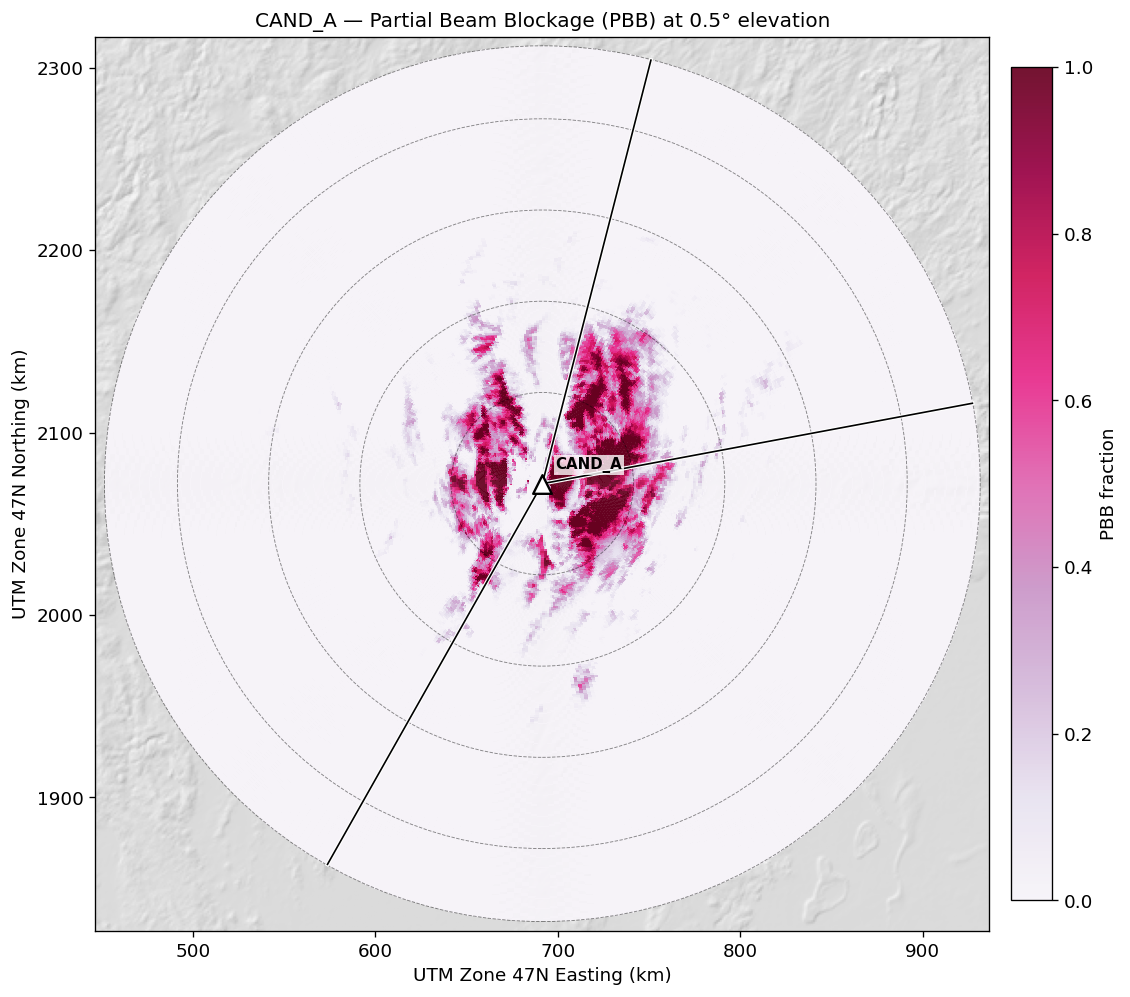

In [20]:

# ============================================================
# STEP 20 — Figure 2: PBB map
# ============================================================

fig, ax = plt.subplots(
    figsize=(10.0, 9.0)
)

ax.imshow(
    hillshade,
    extent=dem_extent_km,
    origin="upper",
    cmap="gray",
    alpha=0.38,
    zorder=0,
)

m = ax.pcolormesh(
    gate_x_m / 1000.0,
    gate_y_m / 1000.0,
    pbb,
    cmap=BLOCKAGE_CMAP,
    vmin=BLOCKAGE_VMIN,
    vmax=BLOCKAGE_VMAX,
    shading="auto",
    alpha=0.92,
    zorder=2,
)

add_focus_site_and_rings(ax)

for az in SELECTED_AZIMUTHS_DEG:
    az_idx = int(round(az)) % 360

    line, = ax.plot(
        gate_x_m[az_idx] / 1000.0,
        gate_y_m[az_idx] / 1000.0,
        linewidth=1.0,
        color="black",
        zorder=7,
    )

    line.set_path_effects([
        pe.Stroke(
            linewidth=2.4,
            foreground="white",
        ),
        pe.Normal(),
    ])

ax.set_xlim(
    SITE_X_KM - 245,
    SITE_X_KM + 245,
)

ax.set_ylim(
    SITE_Y_KM - 245,
    SITE_Y_KM + 245,
)

ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(
    "UTM Zone 47N Easting (km)"
)

ax.set_ylabel(
    "UTM Zone 47N Northing (km)"
)

ax.set_title(
    "CAND_A — Partial Beam Blockage (PBB) at 0.5° elevation"
)

cbar = fig.colorbar(
    m,
    ax=ax,
    shrink=0.82,
    pad=0.02,
)

cbar.set_label(
    "PBB fraction"
)

fig.tight_layout()

fig2_path = save_figure(
    fig,
    "Fig04_02_CAND_A_0p5deg_PBB_Map.png",
)

plt.show()



## 21. Figure 3 — CBB Map

CBB map แสดงผลของ terrain obstruction ที่สะสมไปตาม ray

หาก ridge ใกล้ radar ทำให้ CBB สูง ค่าด้านหลัง ridge จะยังคงอย่างน้อยเท่ากับ blockage สูงสุดที่เกิดก่อนหน้า

ดังนั้น CBB map มักแสดง **radial shadow sectors** ได้ชัดกว่า PBB map


/tmp/ipykernel_3195/2240912362.py:18: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(


Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig04_03_CAND_A_0p5deg_CBB_Map.png


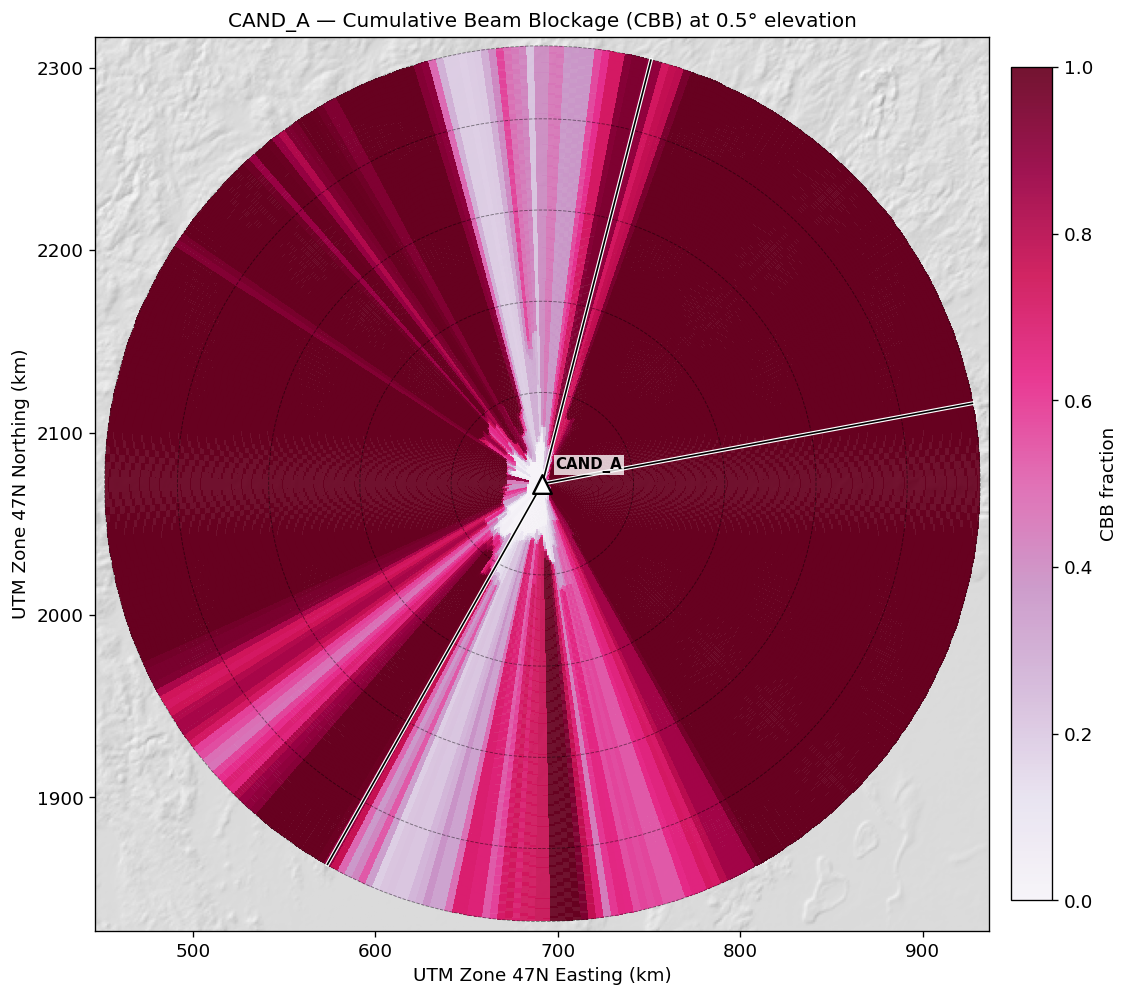

In [21]:

# ============================================================
# STEP 21 — Figure 3: CBB map
# ============================================================

fig, ax = plt.subplots(
    figsize=(10.0, 9.0)
)

ax.imshow(
    hillshade,
    extent=dem_extent_km,
    origin="upper",
    cmap="gray",
    alpha=0.38,
    zorder=0,
)

m = ax.pcolormesh(
    gate_x_m / 1000.0,
    gate_y_m / 1000.0,
    cbb,
    cmap=BLOCKAGE_CMAP,
    vmin=BLOCKAGE_VMIN,
    vmax=BLOCKAGE_VMAX,
    shading="auto",
    alpha=0.92,
    zorder=2,
)

add_focus_site_and_rings(ax)

for az in SELECTED_AZIMUTHS_DEG:
    az_idx = int(round(az)) % 360

    line, = ax.plot(
        gate_x_m[az_idx] / 1000.0,
        gate_y_m[az_idx] / 1000.0,
        linewidth=1.0,
        color="black",
        zorder=7,
    )

    line.set_path_effects([
        pe.Stroke(
            linewidth=2.4,
            foreground="white",
        ),
        pe.Normal(),
    ])

ax.set_xlim(
    SITE_X_KM - 245,
    SITE_X_KM + 245,
)

ax.set_ylim(
    SITE_Y_KM - 245,
    SITE_Y_KM + 245,
)

ax.set_aspect("equal", adjustable="box")

ax.set_xlabel(
    "UTM Zone 47N Easting (km)"
)

ax.set_ylabel(
    "UTM Zone 47N Northing (km)"
)

ax.set_title(
    "CAND_A — Cumulative Beam Blockage (CBB) at 0.5° elevation"
)

cbar = fig.colorbar(
    m,
    ax=ax,
    shrink=0.82,
    pad=0.02,
)

cbar.set_label(
    "CBB fraction"
)

fig.tight_layout()

fig3_path = save_figure(
    fig,
    "Fig04_03_CAND_A_0p5deg_CBB_Map.png",
)

plt.show()



## 22. Figure 4 — CBB ใน Azimuth–Range Coordinates

แผนที่ UTM เหมาะกับการตีความเชิงพื้นที่

แต่ azimuth–range representation เหมาะกับการอ่าน radar geometry โดยตรง

แกนตั้งคือ azimuth และแกนนอนคือ range จึงเห็นว่า blockage sector เริ่มที่ทิศใดและระยะเท่าใด


Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig04_04_CAND_A_0p5deg_CBB_Azimuth_Range.png


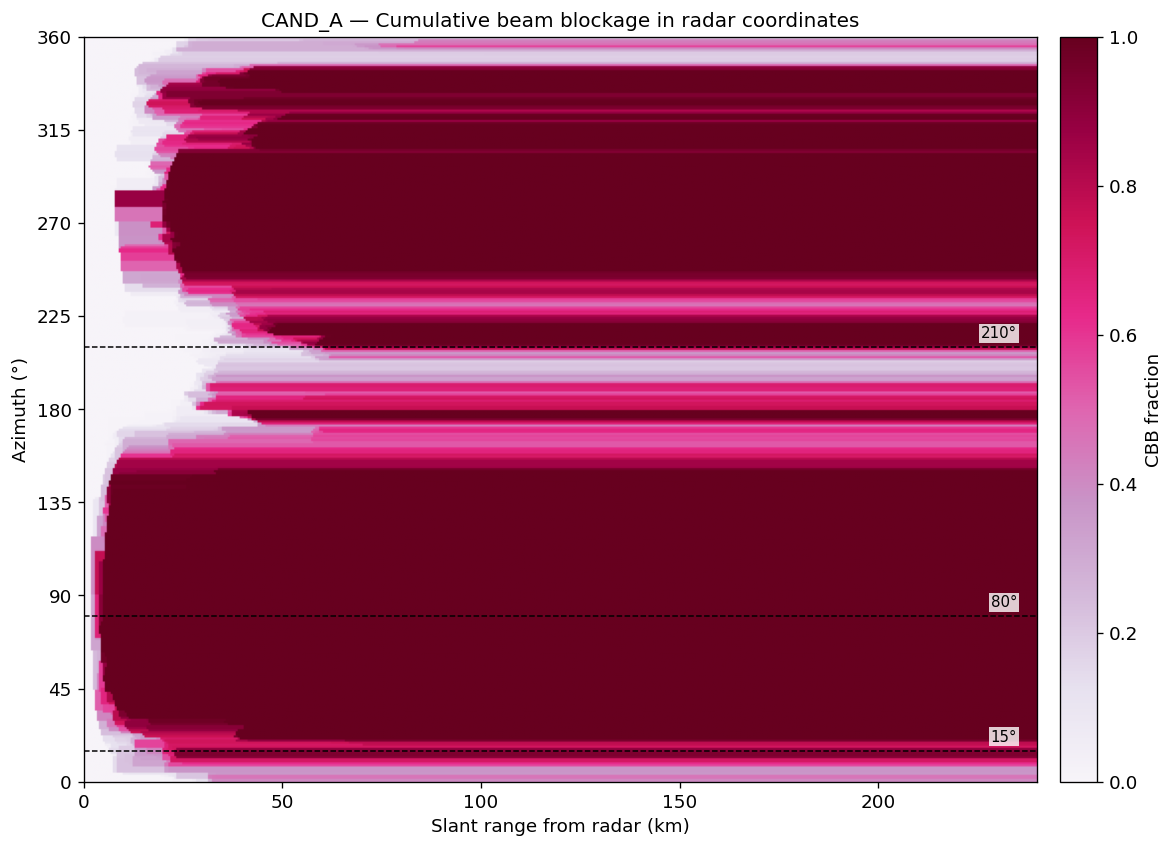

In [22]:

# ============================================================
# STEP 22 — Figure 4: CBB azimuth–range matrix
# ============================================================

fig, ax = plt.subplots(
    figsize=(10.5, 7.2)
)

m = ax.imshow(
    cbb,
    cmap=BLOCKAGE_CMAP,
    vmin=BLOCKAGE_VMIN,
    vmax=BLOCKAGE_VMAX,
    origin="lower",
    aspect="auto",
    extent=[
        range_km[0],
        range_km[-1],
        -0.5,
        359.5,
    ],
)

for az in SELECTED_AZIMUTHS_DEG:
    ax.axhline(
        az,
        linewidth=0.9,
        linestyle="--",
        color="black",
    )

    ax.text(
        range_km[-1] * 0.98,
        az + 3,
        f"{az:.0f}°",
        ha="right",
        va="bottom",
        fontsize=9,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.80,
            "pad": 1.2,
        },
    )

ax.set_xlabel(
    "Slant range from radar (km)"
)

ax.set_ylabel(
    "Azimuth (°)"
)

ax.set_yticks(
    np.arange(0, 361, 45)
)

ax.set_xlim(0, 240)
ax.set_ylim(0, 360)

ax.set_title(
    "CAND_A — Cumulative beam blockage in radar coordinates"
)

cbar = fig.colorbar(
    m,
    ax=ax,
    pad=0.02,
)

cbar.set_label(
    "CBB fraction"
)

fig.tight_layout()

fig4_path = save_figure(
    fig,
    "Fig04_04_CAND_A_0p5deg_CBB_Azimuth_Range.png",
)

plt.show()



# Part H — Selected-Ray Interpretation

## 23. Figures 5–7 — Terrain, Beam, PBB และ CBB ตาม Ray

ในแต่ละ figure:

แกนซ้ายแสดง

- terrain elevation
- lower beam edge
- beam centre
- upper beam edge

แกนขวาแสดง

- PBB
- CBB

สี PBB/CBB มาจาก `PuRd` palette เดียวกับ blockage maps

เส้น threshold ที่ 0.10 และ 0.50 ใช้ช่วยอ่านระยะ D10/D50


Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig04_05_CAND_A_Az015_0p5deg_Terrain_PBB_CBB_Profile.png


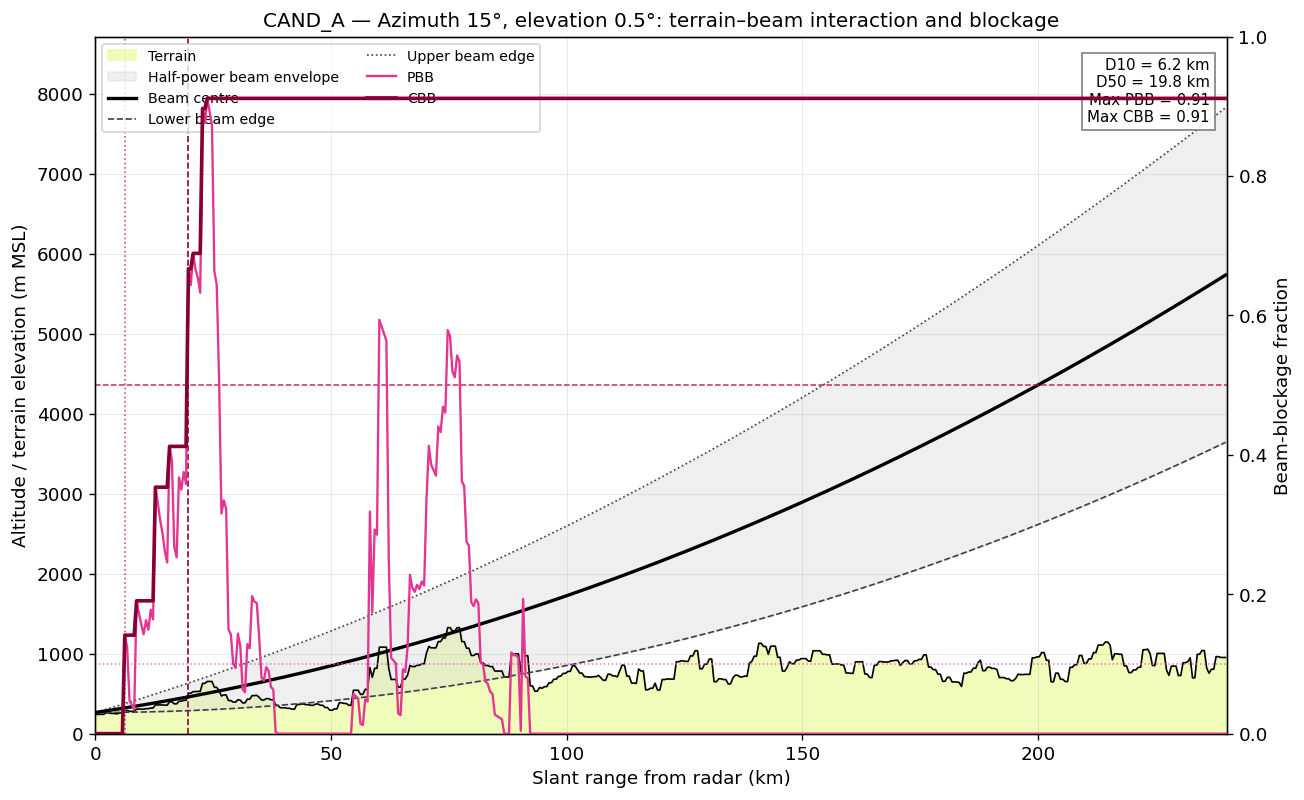

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig04_06_CAND_A_Az080_0p5deg_Terrain_PBB_CBB_Profile.png


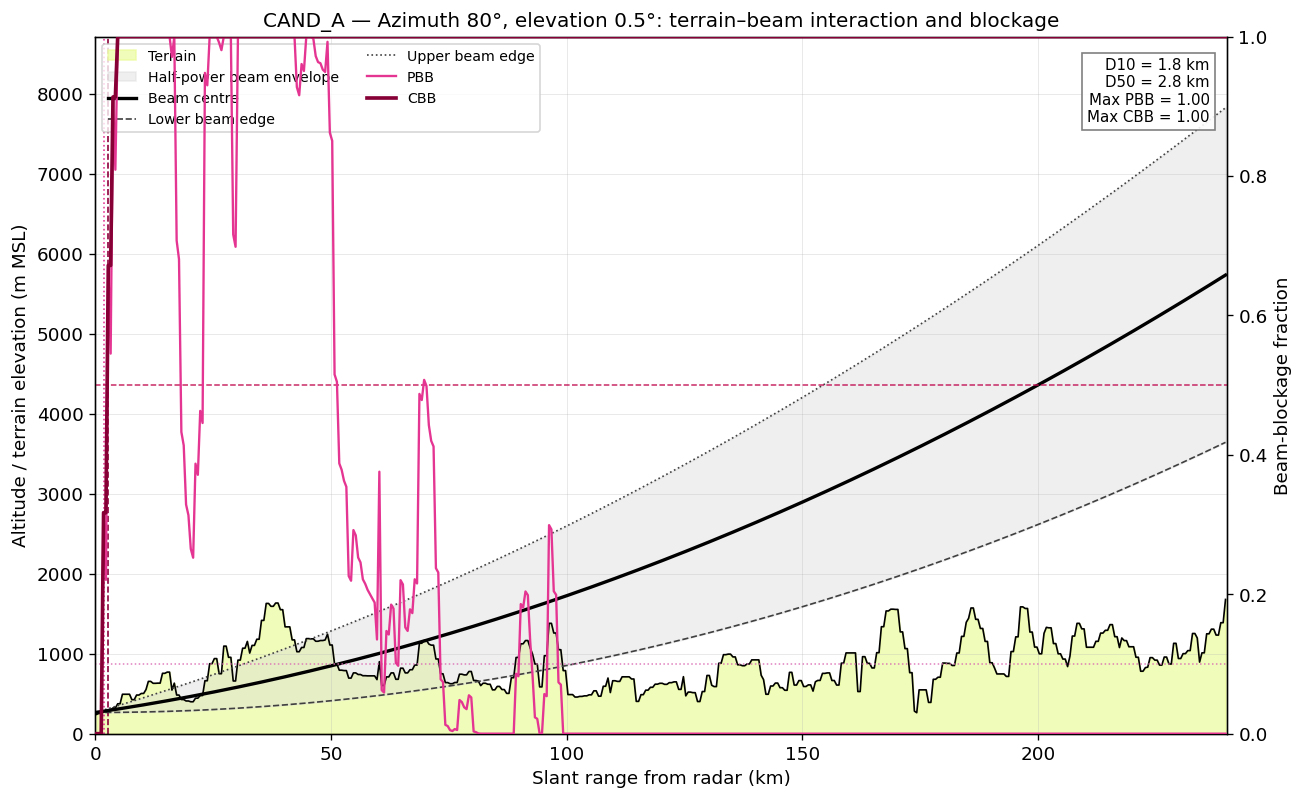

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig04_07_CAND_A_Az210_0p5deg_Terrain_PBB_CBB_Profile.png


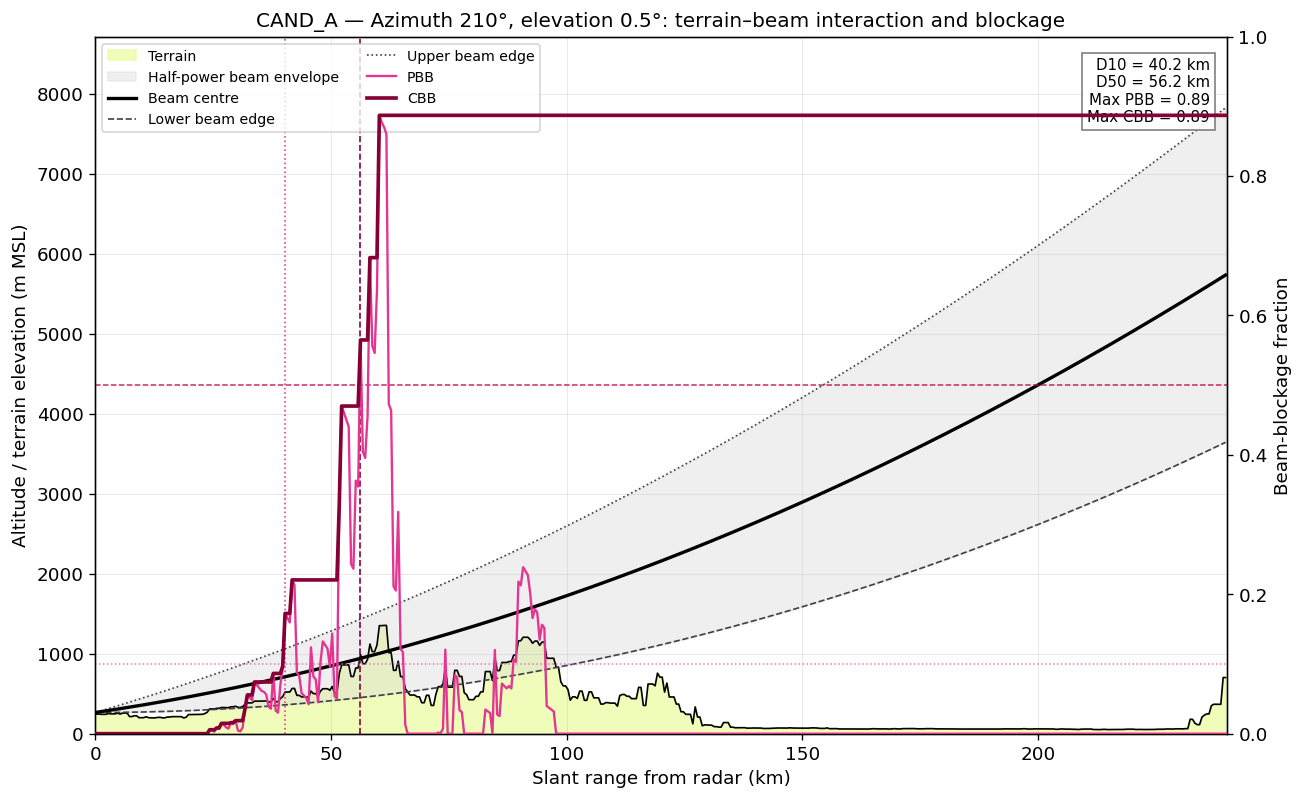

In [23]:

# ============================================================
# STEP 23 — Figures 5–7: selected-ray PBB/CBB profiles
# ============================================================

profile_paths = []

for fig_number, az in enumerate(
    SELECTED_AZIMUTHS_DEG,
    start=5,
):
    az_idx = int(round(az)) % 360

    terrain_ray = terrain_msl_m[az_idx, :]
    center_ray = beam_center_msl_m[az_idx, :]
    lower_ray = beam_lower_msl_m[az_idx, :]
    upper_ray = beam_upper_msl_m[az_idx, :]
    pbb_ray = pbb[az_idx, :]
    cbb_ray = cbb[az_idx, :]

    diag = selected_diagnostics[
        selected_diagnostics[
            "azimuth_deg"
        ] == az
    ].iloc[0]

    d10 = diag[
        "D10_first_CBB_ge_0p10_km"
    ]

    d50 = diag[
        "D50_first_CBB_ge_0p50_km"
    ]

    fig, ax = plt.subplots(
        figsize=(11.0, 6.8)
    )

    ax.fill_between(
        range_km,
        0.0,
        terrain_ray,
        color=TERRAIN_PROFILE_COLOR,
        alpha=0.65,
        label="Terrain",
        zorder=1,
    )

    ax.plot(
        range_km,
        terrain_ray,
        color="black",
        linewidth=1.0,
        zorder=2,
    )

    ax.fill_between(
        range_km,
        lower_ray,
        upper_ray,
        color="0.85",
        alpha=0.40,
        label="Half-power beam envelope",
        zorder=1,
    )

    ax.plot(
        range_km,
        center_ray,
        color="black",
        linewidth=2.0,
        label="Beam centre",
        zorder=4,
    )

    ax.plot(
        range_km,
        lower_ray,
        color="0.25",
        linewidth=1.0,
        linestyle="--",
        label="Lower beam edge",
        zorder=3,
    )

    ax.plot(
        range_km,
        upper_ray,
        color="0.25",
        linewidth=1.0,
        linestyle=":",
        label="Upper beam edge",
        zorder=3,
    )

    ax2 = ax.twinx()

    ax2.plot(
        range_km,
        pbb_ray,
        color=PBB_LINE_COLOR,
        linewidth=1.4,
        label="PBB",
        zorder=6,
    )

    ax2.plot(
        range_km,
        cbb_ray,
        color=CBB_LINE_COLOR,
        linewidth=2.2,
        label="CBB",
        zorder=7,
    )

    ax2.axhline(
        CLEAR_THRESHOLD,
        color=mpl.colormaps[BLOCKAGE_CMAP](0.48),
        linewidth=0.9,
        linestyle=":",
        alpha=0.9,
    )

    ax2.axhline(
        SEVERE_THRESHOLD,
        color=mpl.colormaps[BLOCKAGE_CMAP](0.78),
        linewidth=0.9,
        linestyle="--",
        alpha=0.9,
    )

    if np.isfinite(d10):
        ax.axvline(
            d10,
            color=mpl.colormaps[BLOCKAGE_CMAP](0.58),
            linewidth=1.0,
            linestyle=":",
        )

    if np.isfinite(d50):
        ax.axvline(
            d50,
            color=mpl.colormaps[BLOCKAGE_CMAP](0.90),
            linewidth=1.0,
            linestyle="--",
        )

    ax.set_xlim(0, 240)

    finite_y = np.concatenate([
        terrain_ray[np.isfinite(terrain_ray)],
        upper_ray[np.isfinite(upper_ray)],
    ])

    if finite_y.size:
        y_upper = (
            np.nanpercentile(
                finite_y,
                99.8,
            )
            * 1.12
        )
    else:
        y_upper = 5000.0

    ax.set_ylim(
        0,
        max(y_upper, 2500.0),
    )

    ax2.set_ylim(0.0, 1.0)

    ax.set_xlabel(
        "Slant range from radar (km)"
    )

    ax.set_ylabel(
        "Altitude / terrain elevation (m MSL)"
    )

    ax2.set_ylabel(
        "Beam-blockage fraction"
    )

    ax.set_title(
        f"CAND_A — Azimuth {az:.0f}°, elevation 0.5°: "
        "terrain–beam interaction and blockage"
    )

    ax.grid(
        True,
        linewidth=0.4,
        alpha=0.40,
    )

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()

    combined = {}

    for h, label in zip(
        h1 + h2,
        l1 + l2,
    ):
        if label not in combined:
            combined[label] = h

    ax.legend(
        combined.values(),
        combined.keys(),
        loc="upper left",
        ncol=2,
        fontsize=8.5,
    )

    d10_text = (
        f"{d10:.1f} km"
        if np.isfinite(d10)
        else "not reached"
    )

    d50_text = (
        f"{d50:.1f} km"
        if np.isfinite(d50)
        else "not reached"
    )

    info = (
        f"D10 = {d10_text}\n"
        f"D50 = {d50_text}\n"
        f"Max PBB = {np.nanmax(pbb_ray):.2f}\n"
        f"Max CBB = {np.nanmax(cbb_ray):.2f}"
    )

    ax2.text(
        0.985,
        0.97,
        info,
        transform=ax2.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox={
            "facecolor": "white",
            "edgecolor": "0.45",
            "alpha": 0.90,
            "pad": 3.0,
        },
    )

    fig.tight_layout()

    az_tag = (
        f"{int(round(az)) % 360:03d}"
    )

    path = save_figure(
        fig,
        (
            f"Fig04_{fig_number:02d}_"
            f"CAND_A_Az{az_tag}_0p5deg_"
            "Terrain_PBB_CBB_Profile.png"
        ),
    )

    profile_paths.append(
        str(path)
    )

    plt.show()



## 24. Figure 8 — Maximum PBB/CBB ตาม Azimuth

สำหรับแต่ละ azimuth เราหา

$$
\max_r(PBB)
$$

และ

$$
\max_r(CBB)
$$

กราฟนี้ช่วยระบุ directional sectors ที่มี terrain shielding เด่น


Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig04_08_CAND_A_0p5deg_Maximum_Blockage_by_Azimuth.png


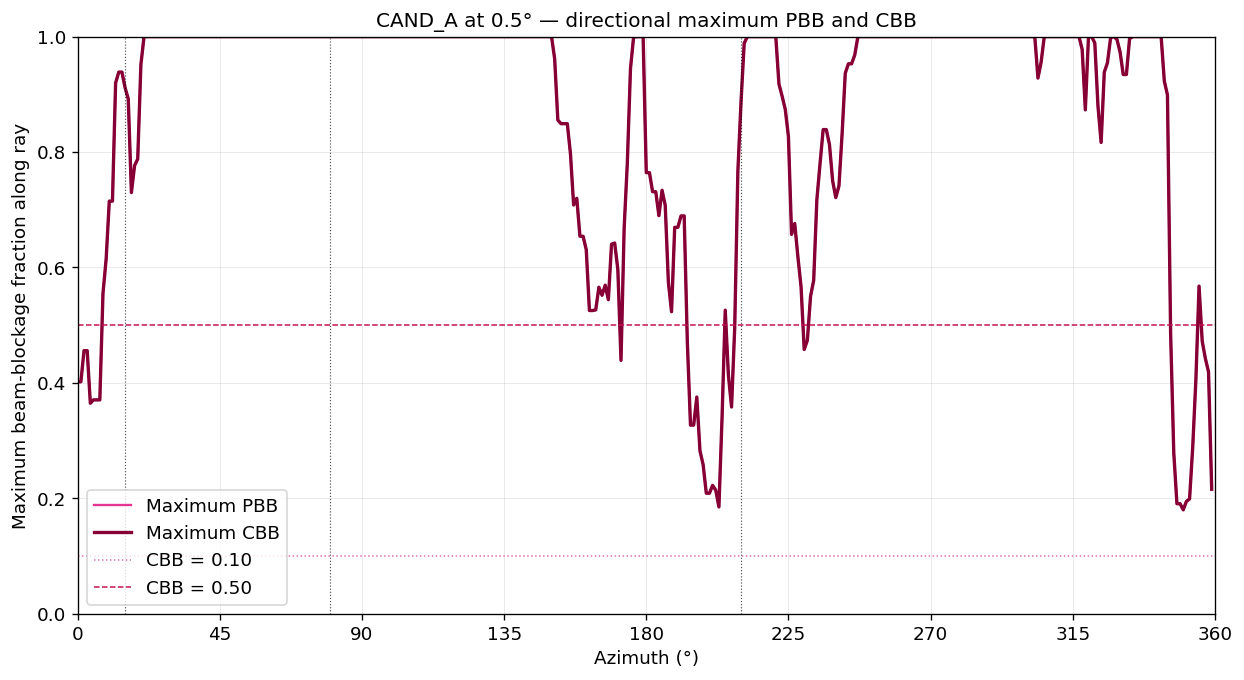

In [24]:

# ============================================================
# STEP 24 — Figure 8: maximum blockage by azimuth
# ============================================================

max_pbb_by_az = np.nanmax(
    pbb,
    axis=1,
)

max_cbb_by_az = np.nanmax(
    cbb,
    axis=1,
)

fig, ax = plt.subplots(
    figsize=(10.5, 5.8)
)

ax.plot(
    AZIMUTHS_ALL_DEG,
    max_pbb_by_az,
    color=PBB_LINE_COLOR,
    linewidth=1.4,
    label="Maximum PBB",
)

ax.plot(
    AZIMUTHS_ALL_DEG,
    max_cbb_by_az,
    color=CBB_LINE_COLOR,
    linewidth=2.0,
    label="Maximum CBB",
)

ax.axhline(
    CLEAR_THRESHOLD,
    color=mpl.colormaps[BLOCKAGE_CMAP](0.48),
    linewidth=0.9,
    linestyle=":",
    label="CBB = 0.10",
)

ax.axhline(
    SEVERE_THRESHOLD,
    color=mpl.colormaps[BLOCKAGE_CMAP](0.78),
    linewidth=0.9,
    linestyle="--",
    label="CBB = 0.50",
)

for az in SELECTED_AZIMUTHS_DEG:
    ax.axvline(
        az,
        linewidth=0.7,
        linestyle=":",
        color="black",
        alpha=0.7,
    )

ax.set_xlim(0, 359)
ax.set_ylim(0, 1)

ax.set_xticks(
    np.arange(0, 361, 45)
)

ax.set_xlabel(
    "Azimuth (°)"
)

ax.set_ylabel(
    "Maximum beam-blockage fraction along ray"
)

ax.set_title(
    "CAND_A at 0.5° — directional maximum PBB and CBB"
)

ax.grid(
    True,
    linewidth=0.4,
    alpha=0.4,
)

ax.legend(
    loc="best",
)

fig.tight_layout()

fig8_path = save_figure(
    fig,
    "Fig04_08_CAND_A_0p5deg_Maximum_Blockage_by_Azimuth.png",
)

plt.show()



# Part I — การตีความผลอย่างถูกต้อง

## 25. วิธีอ่าน PBB Map

PBB ตอบคำถามว่า

> ณ gate นี้ terrain ตัดหน้าตัด half-power beam มากเท่าใด?

จึงเป็น **local geometric quantity**

PBB ที่สูงบน ridge และต่ำลงด้านหลัง ridge เป็นสิ่งที่เกิดขึ้นได้



## 26. วิธีอ่าน CBB Map

CBB ตอบคำถามว่า

> เมื่อเดินทางจาก radar มาถึง gate นี้ ลำบีมเคยถูก terrain บังมากที่สุดเท่าใด?

จึงเป็น **path-dependent quantity**

พื้นที่ด้านหลัง terrain obstacle มักเกิด radial shadow sector



## 27. PBB/CBB ไม่ได้บอกทุกอย่างเกี่ยวกับ Radar Site

แม้ CBB เป็น metric สำคัญ แต่การเลือกตำแหน่ง radar จริงยังต้องพิจารณา

- coverage mission
- target range
- target elevation
- antenna/tower height
- accessibility
- infrastructure
- electromagnetic interference
- land ownership
- maintenance
- climatological storm direction
- QPE/QPN requirements

ดังนั้น Notebook นี้ประเมินเฉพาะ

$$
\boxed{
\mathrm{Terrain\ visibility}
}
$$

ไม่ใช่ final engineering site-selection score



## 28. แบบฝึกคิด

### CORE

1. หาก terrain ผ่าน beam centre ค่า PBB ควรประมาณเท่าใด?
2. เพราะเหตุใด CBB ไม่ลดลงด้านหลัง ridge?
3. หา azimuth ที่มี maximum CBB สูงที่สุด
4. เปรียบเทียบ PBB และ CBB บน selected ray เดียวกัน

### ADVANCED

5. อธิบายว่าทำไม PBB อาจลดลงหลังผ่านภูเขา แต่ CBB ไม่ลดลง
6. ทดลองเปลี่ยน beamwidth จาก 1.0° เป็น 0.8° แล้วอภิปรายผล
7. ทดลองเปลี่ยน antenna height แล้วอภิปราย near-range blockage
8. เปลี่ยน elevation จาก 0.5° เป็น 1.0° และตั้งสมมติฐานก่อนรัน

### RESEARCH EXTENSION

9. อธิบายว่าความไม่แน่นอนของ DEM propagate ไปสู่ PBB/CBB อย่างไร
10. ในสภาวะ superrefraction เหตุใด standard $k=4/3$ อาจทำให้ blockage estimate มี bias?
11. ออกแบบการตรวจสอบ beam-blockage model ด้วย observed radar reflectivity climatology หรือ clutter/visibility patterns


In [25]:

# ============================================================
# STEP 25 — Save metadata and final readiness check
# ============================================================

output_metadata = {
    "site_id": FOCUS_SITE_ID,
    "site_name": str(site["site_name"]),
    "elevation_deg": FOCUS_ELEVATION_DEG,
    "beamwidth_deg": BEAMWIDTH_DEG,
    "k_factor": K_STANDARD,
    "earth_radius_m": EARTH_RADIUS_M,
    "ground_elevation_msl_m": RADAR_GROUND_MSL_M,
    "antenna_agl_teaching_assumption_m": ANTENNA_AGL_M,
    "radar_altitude_msl_m": RADAR_ALTITUDE_MSL_M,
    "dem_path": str(DEM_PATH),
    "dem_sampling": (
        "Containing 1-km MAX DEM raster cell; no extra interpolation"
    ),
    "wradlib_version": wrl.__version__,
    "wradlib_geometry_function": (
        "wradlib.georef.polar.spherical_to_proj"
    ),
    "wradlib_pbb_function": (
        "wradlib.qual.beam_block_frac"
    ),
    "wradlib_cbb_function": (
        "wradlib.qual.cum_beam_block_frac"
    ),
    "clear_threshold": CLEAR_THRESHOLD,
    "severe_threshold": SEVERE_THRESHOLD,
    "selected_azimuths_deg": [
        float(v)
        for v in SELECTED_AZIMUTHS_DEG
    ],
    "terrain_agreement_with_notebook03_pct": (
        terrain_match_pct
    ),
    "terrain_mae_vs_notebook03_m": (
        terrain_mae_m
    ),
    "max_pbb_manual_validation_difference": (
        max_pbb_difference
    ),
    "max_cbb_running_max_validation_difference": (
        max_cbb_difference
    ),
    "array_output": str(array_path),
    "summary_table": str(summary_csv),
    "selected_ray_table": str(selected_diag_csv),
}

metadata_path = (
    METADATA_DIR /
    "04_CAND_A_0p5deg_PBB_CBB_Metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        output_metadata,
        f,
        indent=2,
        ensure_ascii=False,
    )

final_checks = {
    "wradlib geometry shape is 360 × 480": (
        beam_center_msl_m.shape
        == (NRAYS, NBINS)
    ),
    "≥99% terrain samples valid": (
        (1.0 - missing_mask.mean())
        >= 0.99
    ),
    "PBB lies within 0–1": (
        np.nanmin(pbb) >= 0.0
        and np.nanmax(pbb) <= 1.0
    ),
    "CBB lies within 0–1": (
        np.nanmin(cbb) >= 0.0
        and np.nanmax(cbb) <= 1.0
    ),
    "Manual PBB agrees with wradlib": (
        max_pbb_difference < 1e-5
    ),
    "CBB is monotonic along complete rays": (
        monotonic_ok
    ),
    "wradlib CBB agrees with running maximum": (
        max_cbb_difference < 1e-6
    ),
    "PBB/CBB array saved": array_path.exists(),
    "Summary CSV saved": summary_csv.exists(),
    "Selected-ray diagnostics saved": selected_diag_csv.exists(),
    "Metadata JSON saved": metadata_path.exists(),
}

print("=" * 84)
print("NOTEBOOK 04 — FINAL READINESS CHECK")
print("=" * 84)

all_ok = True

for label, status in final_checks.items():
    print(
        ("✓" if status else "✗"),
        label,
    )

    all_ok = (
        all_ok
        and status
    )

print("=" * 84)

print("\nKey outputs")
print("-----------")
print("Arrays      :", array_path)
print("Summary     :", summary_csv)
print("Diagnostics :", selected_diag_csv)
print("Metadata    :", metadata_path)

if all_ok:
    print(
        "\n✓ PBB/CBB WORKFLOW READY — proceed to the next "
        "notebook for multi-elevation comparison."
    )
else:
    raise RuntimeError(
        "One or more PBB/CBB QC checks failed."
    )


NOTEBOOK 04 — FINAL READINESS CHECK
✓ wradlib geometry shape is 360 × 480
✓ ≥99% terrain samples valid
✓ PBB lies within 0–1
✓ CBB lies within 0–1
✓ Manual PBB agrees with wradlib
✓ CBB is monotonic along complete rays
✓ wradlib CBB agrees with running maximum
✓ PBB/CBB array saved
✓ Summary CSV saved
✓ Selected-ray diagnostics saved
✓ Metadata JSON saved

Key outputs
-----------
Arrays      : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/03_results/04_CAND_A_0p5deg_PBB_CBB_360x480.npz
Summary     : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/04_CAND_A_0p5deg_PBB_CBB_Gate_Summary.csv
Diagnostics : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/04_CAND_A_0p5deg_SelectedRay_CBB_Diagnostics.csv
Metadata    : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/02_metadata/04_CAND_A_0p5deg_PBB_CBB_Metadata.json

✓ PBB/CBB WORKFLOW READY — proceed to the next notebook for multi-elevation comparison.



# 29. สรุปบทเรียน

Notebook นี้เปลี่ยนจาก terrain–beam geometry ไปสู่ quantitative beam blockage

เริ่มจาก

$$
y
=
H_t-H_b
$$

normalize ด้วย beam radius

$$
q
=
\frac{y}{a}
$$

แล้วคำนวณ PBB จาก circle-segment interception

จากนั้นแปลง local blockage ให้เป็น cumulative blockage

$$
CBB_i
=
\max_{j\le i}
PBB_j
$$

จึงได้ workflow

$$
\boxed{
DEM
\rightarrow
Radar\ geometry
\rightarrow
Terrain\ sampling
\rightarrow
PBB
\rightarrow
CBB
\rightarrow
Spatial\ interpretation
}
$$

### Output สำคัญ

```text
03_results/
└── 04_CAND_A_0p5deg_PBB_CBB_360x480.npz

05_tables/
├── 04_CAND_A_0p5deg_PBB_CBB_Gate_Summary.csv
└── 04_CAND_A_0p5deg_SelectedRay_CBB_Diagnostics.csv

02_metadata/
└── 04_CAND_A_0p5deg_PBB_CBB_Metadata.json
```

### Figures

```text
04_figures/
├── Fig04_01_Conceptual_Partial_Beam_Blockage.png
├── Fig04_02_CAND_A_0p5deg_PBB_Map.png
├── Fig04_03_CAND_A_0p5deg_CBB_Map.png
├── Fig04_04_CAND_A_0p5deg_CBB_Azimuth_Range.png
├── Fig04_05_CAND_A_Az015_0p5deg_Terrain_PBB_CBB_Profile.png
├── Fig04_06_CAND_A_Az080_0p5deg_Terrain_PBB_CBB_Profile.png
├── Fig04_07_CAND_A_Az210_0p5deg_Terrain_PBB_CBB_Profile.png
└── Fig04_08_CAND_A_0p5deg_Maximum_Blockage_by_Azimuth.png
```

---

## References

Bech, J., Codina, B., Lorente, J., & Bebbington, D. (2003). *The sensitivity of single polarization weather radar beam blockage correction to variability in the vertical refractivity gradient*. Journal of Atmospheric and Oceanic Technology, 20(6), 845–855.

wradlib documentation: `wradlib.qual.beam_block_frac` and `wradlib.qual.cum_beam_block_frac`.

---

## Next — Notebook 05

บทถัดไปจะขยายจาก

$$
\mathrm{CAND\_A}
\times
0.5^\circ
$$

ไปเป็นหลาย elevation angles

$$
0.5^\circ,\ 1.0^\circ,\ 1.5^\circ,\ 2.0^\circ
$$

เพื่อศึกษาว่า **การยก elevation angle ช่วยลด terrain blockage มากเพียงใด และต้องแลกกับ beam altitude ที่สูงขึ้นเท่าใด**
